In [157]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

In [158]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

In [159]:
# Extract X and y

X = mnist.data
y = mnist.target.astype(int)

In [160]:
X.shape

(70000, 784)

In [161]:
# Split into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [162]:
# Define activation functions

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [163]:
# Find out the number of unique classes

num_classes = len(np.unique(y))
num_classes

10

In [164]:
class HiddenLayer():
    def __init__(self, x1, x2, act_func):
        self.weights = np.random.randn(x1, x2) * np.sqrt(2.0 / x1)
        self.bias = np.zeros(x2)
        self.act_func = act_func

    def forward_step(self, x):
        z = np.dot(x, self.weights) + self.bias
        y = self.act_func(z)

        return x, z, y

class LayerData():
    def __init__(self, inputs, inter, outputs):
        self.inputs = inputs
        self.inter = inter
        self.outputs = outputs
        
class MNISTSolver():
    def __init__(self):
        self.lyr1 = HiddenLayer(X.shape[1], 64, relu)
        self.lyr2 = HiddenLayer(64, 32, relu)
        self.lyr3 = HiddenLayer(32, 16, relu)
        self.lyr4 = HiddenLayer(16, num_classes, softmax)

    def get_layers(self):
        return [self.lyr1, self.lyr2, self.lyr3, self.lyr4]

    def forward(self, _input): 

        inputs  = [] # Inputs
        inter = [] # Intermediary values (z)
        outputs = [] # Outputs

        x, z, y = self.lyr1.forward_step(_input)
        inputs.append(x)
        inter.append(z)
        outputs.append(y)
    
        x, z, y = self.lyr2.forward_step(y)
        inputs.append(x)
        inter.append(z)
        outputs.append(y)
        
        x, z, y = self.lyr3.forward_step(y)
        inputs.append(x)
        inter.append(z)
        outputs.append(y)
        
        x, z, y = self.lyr4.forward_step(y)
        inputs.append(x)
        inter.append(z)
        outputs.append(y)

        layer_data = LayerData(inputs, inter, outputs)

        return y, layer_data

In [165]:
# Define the ANN

model = MNISTSolver()

In [166]:
# Define the loss function

def cross_entropy_loss(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.log(y_pred[y_true])

In [167]:
def train_model(model, X, y, batch_size, epochs, learning_rate):
    layers = model.get_layers()

    for epoch in range(epochs):
        total_loss = 0
        curr_batch = 0

        while curr_batch < X.shape[0]:

            add_size = min(batch_size, X.shape[0] - curr_batch)

            X_batch = X[curr_batch:curr_batch + add_size]
            y_batch = y[curr_batch:curr_batch + add_size]

            dWs = [np.zeros_like(layer.weights) for layer in layers]
            dBs = [np.zeros_like(layer.bias) for layer in layers]

            for _x, _y in zip(X_batch, y_batch):

                y_hat, layer_data = model.forward(_x)

                loss = cross_entropy_loss(_y, y_hat)
                total_loss += loss

                reversed_layers = layers[::-1]

                delta = y_hat.copy()
                delta[_y] -= 1

                for idx, layer in enumerate(reversed_layers):
                    data_idx = len(layers) - idx - 1

                    dW = np.outer(layer_data.inputs[data_idx], delta)
                    dB = delta

                    # Find original layer index
                    layer_idx = len(layers) - idx - 1

                    dWs[layer_idx] += dW
                    dBs[layer_idx] += dB

                    if idx != len(reversed_layers) - 1:
                        delta = (delta @ layer.weights.T) * relu_derivative(
                            layer_data.inter[data_idx - 1]
                        )

            for idx, layer in enumerate(layers):
                layer.weights -= learning_rate * (dWs[idx] / add_size)
                layer.bias -= learning_rate * (dBs[idx] / add_size)

            curr_batch += add_size

        print(f"Epoch {epoch + 1}, Loss: {total_loss / X.shape[0]}")

train_model(model, X_train, y_train, batch_size=32, epochs=10, learning_rate=0.001)

Epoch 1, Loss: 2.059282524874374
Epoch 2, Loss: 1.3150240823476287
Epoch 3, Loss: 0.8394409676332707
Epoch 4, Loss: 0.6199804631368125
Epoch 5, Loss: 0.5141305139174159
Epoch 6, Loss: 0.45239070760042926
Epoch 7, Loss: 0.4104327705761778
Epoch 8, Loss: 0.37863689840706477
Epoch 9, Loss: 0.35392616060467147
Epoch 10, Loss: 0.33462654754352433


In [169]:
# Make predictions

y_pred, _ = model.forward(X_test)
y_pred = y_pred.argmax(axis=1)

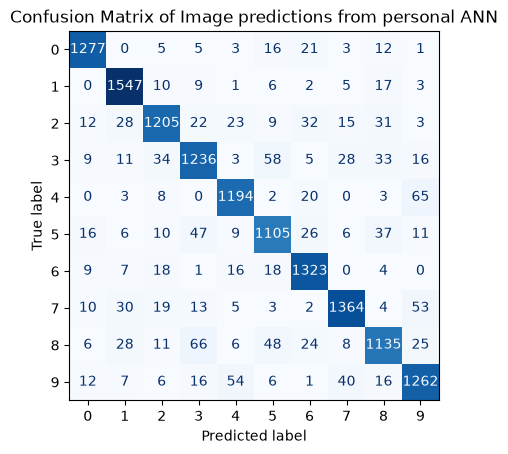

In [170]:
# Find the confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay as CMD

cm = confusion_matrix(y_test, y_pred)

cm_disp = CMD(confusion_matrix=cm)
cm_disp.plot(cmap='Blues', colorbar=False)

plt.title('Confusion Matrix of Image predictions from personal ANN')
plt.show()